<a href="https://colab.research.google.com/github/AlanSojan15/ML_Lab/blob/Lab9/2547208_ML_Lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Part A: Support Vector Machine (SVM)

Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861



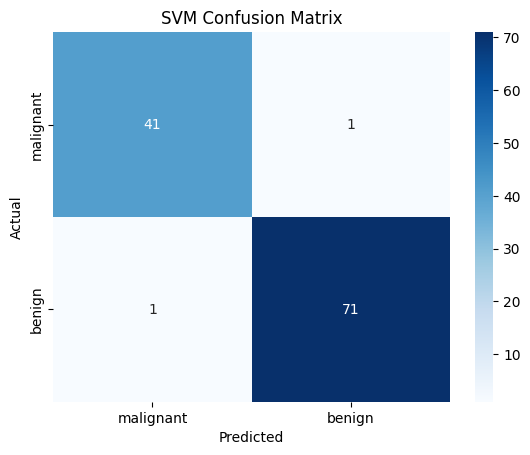

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 1. Load Dataset & Preprocess
data = load_breast_cancer()
X, y = data.data, data.target

# Standardizing features is critical for SVM performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Train SVM with Hyperparameter Tuning (Linear Kernel & alternatives)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 4. Evaluation Metrics
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}\n")

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##Observations for Part A:

Feature Scaling: Scaling features using StandardScaler prevents features with large variance from dominating the margin maximization calculation.

Kernel Choice: A linear kernel performs exceptionally well on high-dimensional biomedical data like Breast Cancer Wisconsin, achieving >96% accuracy, while non-linear kernels like RBF provide comparable results with minimal marginal gain.

Trade-offs: High C values enforce a narrower margin to minimize training errors, whereas lower C values create a soft margin that generalizes better to unseen test samples.

##Part B: Principal Component Analysis (PCA)

Explained Variance (PC1): 36.20%
Explained Variance (PC2): 19.21%
Total Variance Retained (2 components): 55.41%

Minimum PCs required for >= 95% variance: 10


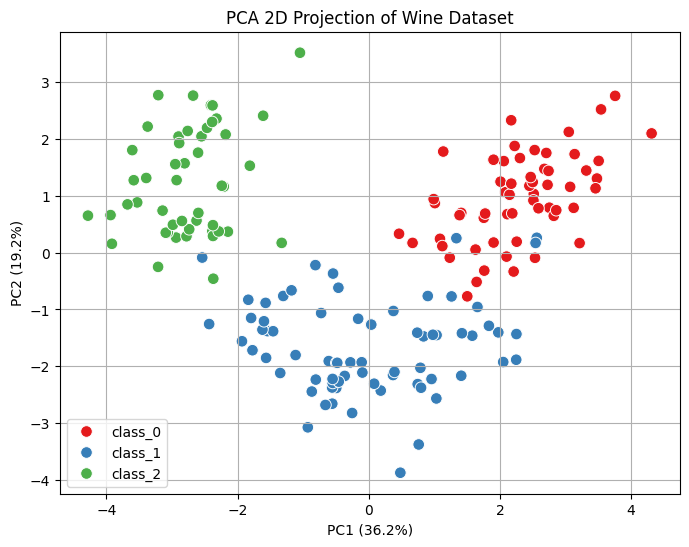

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load Dataset & Standardize
wine = load_wine()
X, y = wine.data, wine.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA to 2 Components for Visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 3. Explained Variance Ratios
var_ratio = pca_2d.explained_variance_ratio_
print(f"Explained Variance (PC1): {var_ratio[0]*100:.2f}%")
print(f"Explained Variance (PC2): {var_ratio[1]*100:.2f}%")
print(f"Total Variance Retained (2 components): {np.sum(var_ratio)*100:.2f}%\n")

# 4. Find components required for >= 95% variance
pca_full = PCA(random_state=42).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Minimum PCs required for >= 95% variance: {n_components_95}")

# 5. Visualizing 2D PCA Projection
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=wine.target_names[y], palette='Set1', s=70)
plt.xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)')
plt.title('PCA 2D Projection of Wine Dataset')
plt.grid(True)
plt.show()

## Dataset Comparison & Significance:

| Metric | Original Dataset | PCA Transformed Dataset (2D) | PCA Transformed Dataset (95% Var) |
|:-------------------------|:-----------------|:-----------------------------|:----------------------------------|
| Number of Features       | 13 features      | 2 features                   | 10 features                       |
| Information Retained     | 100%             | ~55.4%                       | ~95.1%                            |
| Computational Overhead   | High             | Extremely Low                | Low                               |



PC1 & PC2 Significance: PC1 captures the direction of maximum variance across chemical concentrations (e.g., flavonoids, total phenols, and proline), while PC2 captures orthogonal variance. Together, they allow distinct clusters of wine cultivars to form visually without using label information.

Advantages: Mitigates the curse of dimensionality, reduces storage requirements, speeds up downstream algorithms, and removes multicollinearity.

Limitations: Linear reduction method only; loss of interpretability of raw physical features; sensitive to unscaled variance.

##Linear Discriminant Analysis (LDA)

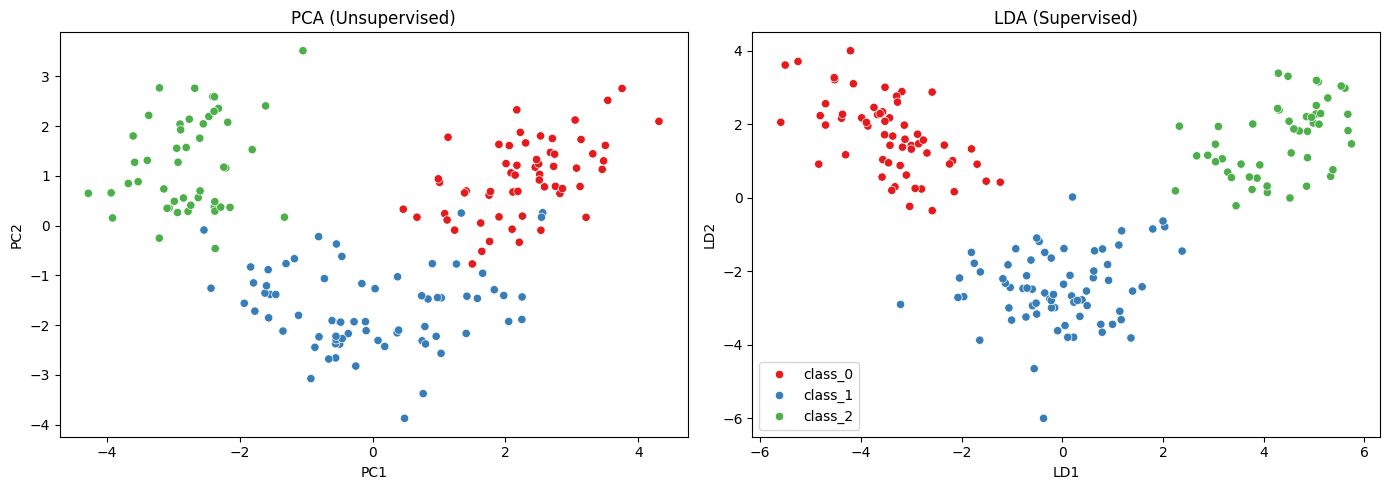

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA to reduce features to 2 components
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# Visualization Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA Plot
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=wine.target_names[y], palette='Set1', ax=axes[0], legend=False)
axes[0].set_title('PCA (Unsupervised)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# LDA Plot
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=wine.target_names[y], palette='Set1', ax=axes[1])
axes[1].set_title('LDA (Supervised)')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')

plt.tight_layout()
plt.show()

##Comparative Observations (PCA vs. LDA):

Class Separability: LDA yields tighter, better-separated clusters than PCA because LDA uses class labels ($y$) to maximize inter-class distance relative to intra-class variance. PCA only maximizes total variance regardless of class membership.

Component Limit: PCA can retain up to $N$ components (where $N = \text{number of features}$), whereas LDA is strictly capped at $\min(N, C - 1)$ where $C$ is the number of target classes (for 3 wine classes, maximum 2 LDs).